# Neurosignature: System Comparison

Compares two CTRNN instances (System A and System B) that differ only in
gain `g`.  Both receive inputs drawn from the same `InputGenerator`.
A shared `VectorDescriptor` maps each trial output to a descriptor
vector `z`.  `SystemComparator` collects descriptor clouds `Z_A` and
`Z_B` over many trials and computes Euclidean, cosine, and Wasserstein
distances between them.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurosignature as ns

np.random.seed(0)
sns.set_context("notebook")
plt.rcParams["axes.formatter.useoffset"] = False

## 1. Shared Architecture

Both systems share the same weight matrices and hyperparameters;
only `g` differs.

In [14]:
n_hidden = 20
n_inputs = 20
n_outputs = 20
dt_ms = 1.0

rng = np.random.default_rng(0)

W_int = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_prop = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_u = ns.relu(
    ns.generate_random_matrix(n_hidden, n_inputs, dist="normal", matrix_type="dense")
)
W_o = ns.relu(
    ns.generate_random_matrix(n_outputs, n_hidden, dist="normal", matrix_type="dense")
)

common_kwargs = dict(
    n_hidden=n_hidden,
    n_inputs=n_inputs,
    n_outputs=n_outputs,
    W_int=W_int,
    W_prop=W_prop,
    W_u=W_u,
    W_o=W_o,
    tau=5.0,
    V_rest=-65.0,
    polarity="excitatory",
    phi="tanh",
    tau_syn_ms=5.0,
    dt_ms=dt_ms,
)

system_a = ns.ContinuousTimeRNN(g=0.0, **common_kwargs)
system_b = ns.ContinuousTimeRNN(g=0.2, **common_kwargs)

print("System A:", system_a)
print("System B:", system_b)

System A: <neurosignature.systems.recurrent_system.ContinuousTimeRNN object at 0x000001C32E528530>
System B: <neurosignature.systems.recurrent_system.ContinuousTimeRNN object at 0x000001C3345FAD20>


## 2. Shared Input Generator & Descriptor

In [15]:
input_gen = ns.InputGenerator(
    n_channels=n_inputs,
    rate_hz=50.0,
    dt_ms=dt_ms,
    seed=42,
)

duration_ms = 4000.0
reference_channel = 0

descriptor_components = [
    ns.ReferenceStd(),
    ns.ReferenceSpectralCentroid(dt_ms=dt_ms),
    ns.ResidualMean(),
    ns.ResidualStd(),
    ns.ResidualEnergy(dt_ms=dt_ms),
    ns.ResidualSpectralCentroidMean(dt_ms=dt_ms),
    ns.ResidualSpectralCentroidStd(dt_ms=dt_ms),
    ns.ResidualParticipationRatio(),
    ns.ResidualMaxEigenvalue(),
    ns.ResidualEigenvalueEntropy(),
    ns.CrossCorrelationMean(),
    ns.TransmissionEfficiency(),
]

vd = ns.VectorDescriptor(descriptor_components, reference_channel=reference_channel)
component_labels = vd.labels()

## 3. Run SystemComparator

In [16]:
n_trials = 100

comparator = ns.SystemComparator(
    input_gen=input_gen,
    simulator_a=ns.Simulator(system_a),
    simulator_b=ns.Simulator(system_b),
    descriptor=vd,
)

results = comparator.compare(n_trials=n_trials, duration_ms=duration_ms, mode="cross")

Z_A = results["Z_A"]
Z_B = results["Z_B"]

print(f"Z_A shape: {Z_A.shape}")
print(f"Z_B shape: {Z_B.shape}")
print(
    f"\nEuclidean  — mean: {results['euclidean']['mean']:.4f},"
    f" std: {results['euclidean']['std']:.4f}"
)
print(
    f"Cosine     — mean: {results['cosine']['mean']:.4f},"
    f" std: {results['cosine']['std']:.4f}"
)
print(f"Wasserstein (n-D): {results['wasserstein']:.4f}")

C:\Users\MainUser\Documents\Repos\neurosignature\neurosignature\math.py:200: RuntimeWarning: overflow encountered in exp
  alpha = t_norm * np.exp(-t_norm)
C:\Users\MainUser\Documents\Repos\neurosignature\neurosignature\math.py:200: RuntimeWarning: overflow encountered in multiply
  alpha = t_norm * np.exp(-t_norm)


Z_A shape: (100, 12)
Z_B shape: (100, 12)

Euclidean  — mean: 7.9444, std: 0.3008
Cosine     — mean: 0.0578, std: 0.0046
Wasserstein (n-D): 7.9377


## 4. Descriptor Clouds: Side-by-Side Heatmaps

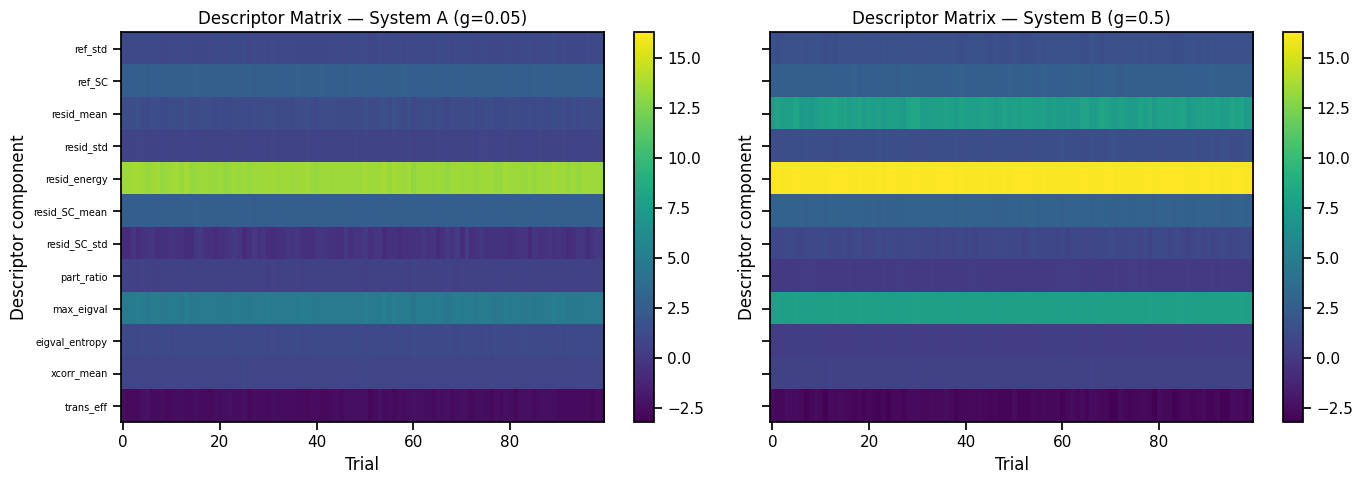

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vmin = min(Z_A.min(), Z_B.min())
vmax = max(Z_A.max(), Z_B.max())

for ax, Z, label in zip(axes, [Z_A, Z_B], ["System A (g=0.05)", "System B (g=0.5)"]):
    im = ax.imshow(Z.T, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Descriptor component")
    ax.set_yticks(range(len(component_labels)))
    ax.set_yticklabels(component_labels, fontsize=7)
    ax.set_title(f"Descriptor Matrix — {label}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 5. Mean ± Std Per Component

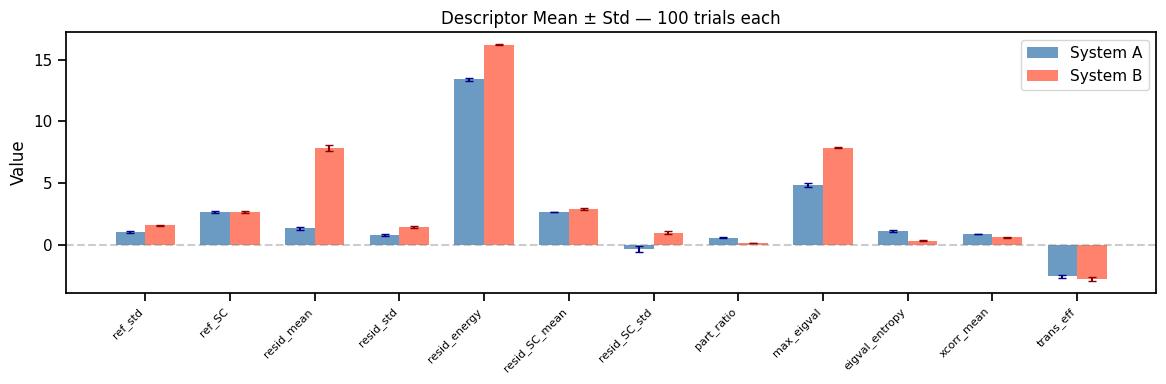

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(component_labels))
width = 0.35

ax.bar(
    x - width / 2,
    Z_A.mean(axis=0),
    width,
    yerr=Z_A.std(axis=0),
    capsize=3,
    alpha=0.8,
    color="steelblue",
    ecolor="navy",
    label="System A",
)
ax.bar(
    x + width / 2,
    Z_B.mean(axis=0),
    width,
    yerr=Z_B.std(axis=0),
    capsize=3,
    alpha=0.8,
    color="tomato",
    ecolor="darkred",
    label="System B",
)

ax.set_xticks(x)
ax.set_xticklabels(component_labels, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_ylabel("Value")
ax.set_title(f"Descriptor Mean ± Std — {n_trials} trials each")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Distance Distributions

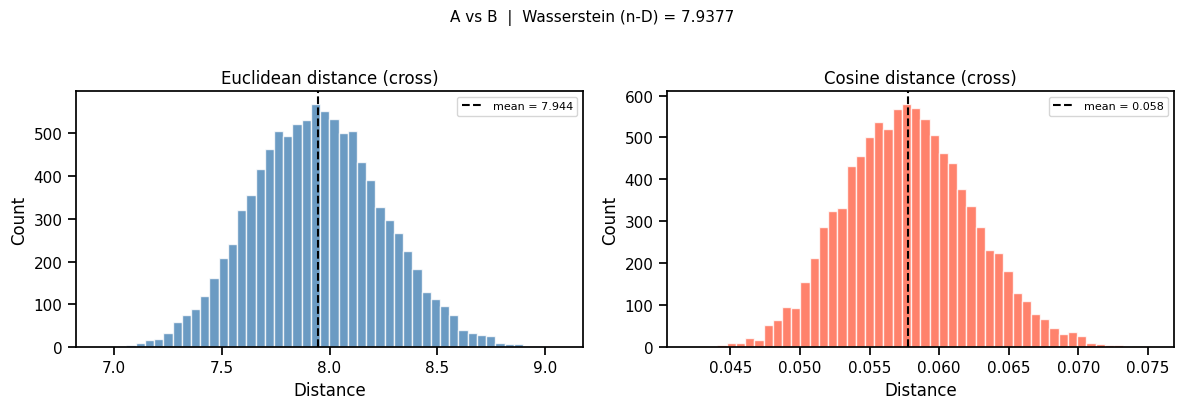

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


def n_bins(n):
    return max(5, min(50, int(np.sqrt(n))))


for ax, key, color, title in zip(
    axes,
    ["euclidean", "cosine"],
    ["steelblue", "tomato"],
    ["Euclidean distance (cross)", "Cosine distance (cross)"],
):
    dists = results[key]["distances"]
    ax.hist(dists, bins=n_bins(len(dists)), color=color, alpha=0.8, edgecolor="white")
    ax.axvline(
        results[key]["mean"],
        color="black",
        linestyle="--",
        label=f"mean = {results[key]['mean']:.3f}",
    )
    ax.set_xlabel("Distance")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    f"A vs B  |  Wasserstein (n-D) = {results['wasserstein']:.4f}", fontsize=11, y=1.02
)

plt.tight_layout()
plt.show()

## 7. Pairwise Joint Histograms

Grid where both rows and columns correspond to descriptor components.
Off-diagonal cells show a 2-D histogram of component i (x) vs component j
(y) for System A (steelblue) and System B (tomato), overlaid with
transparency.  Diagonal cells show per-component marginal histograms.

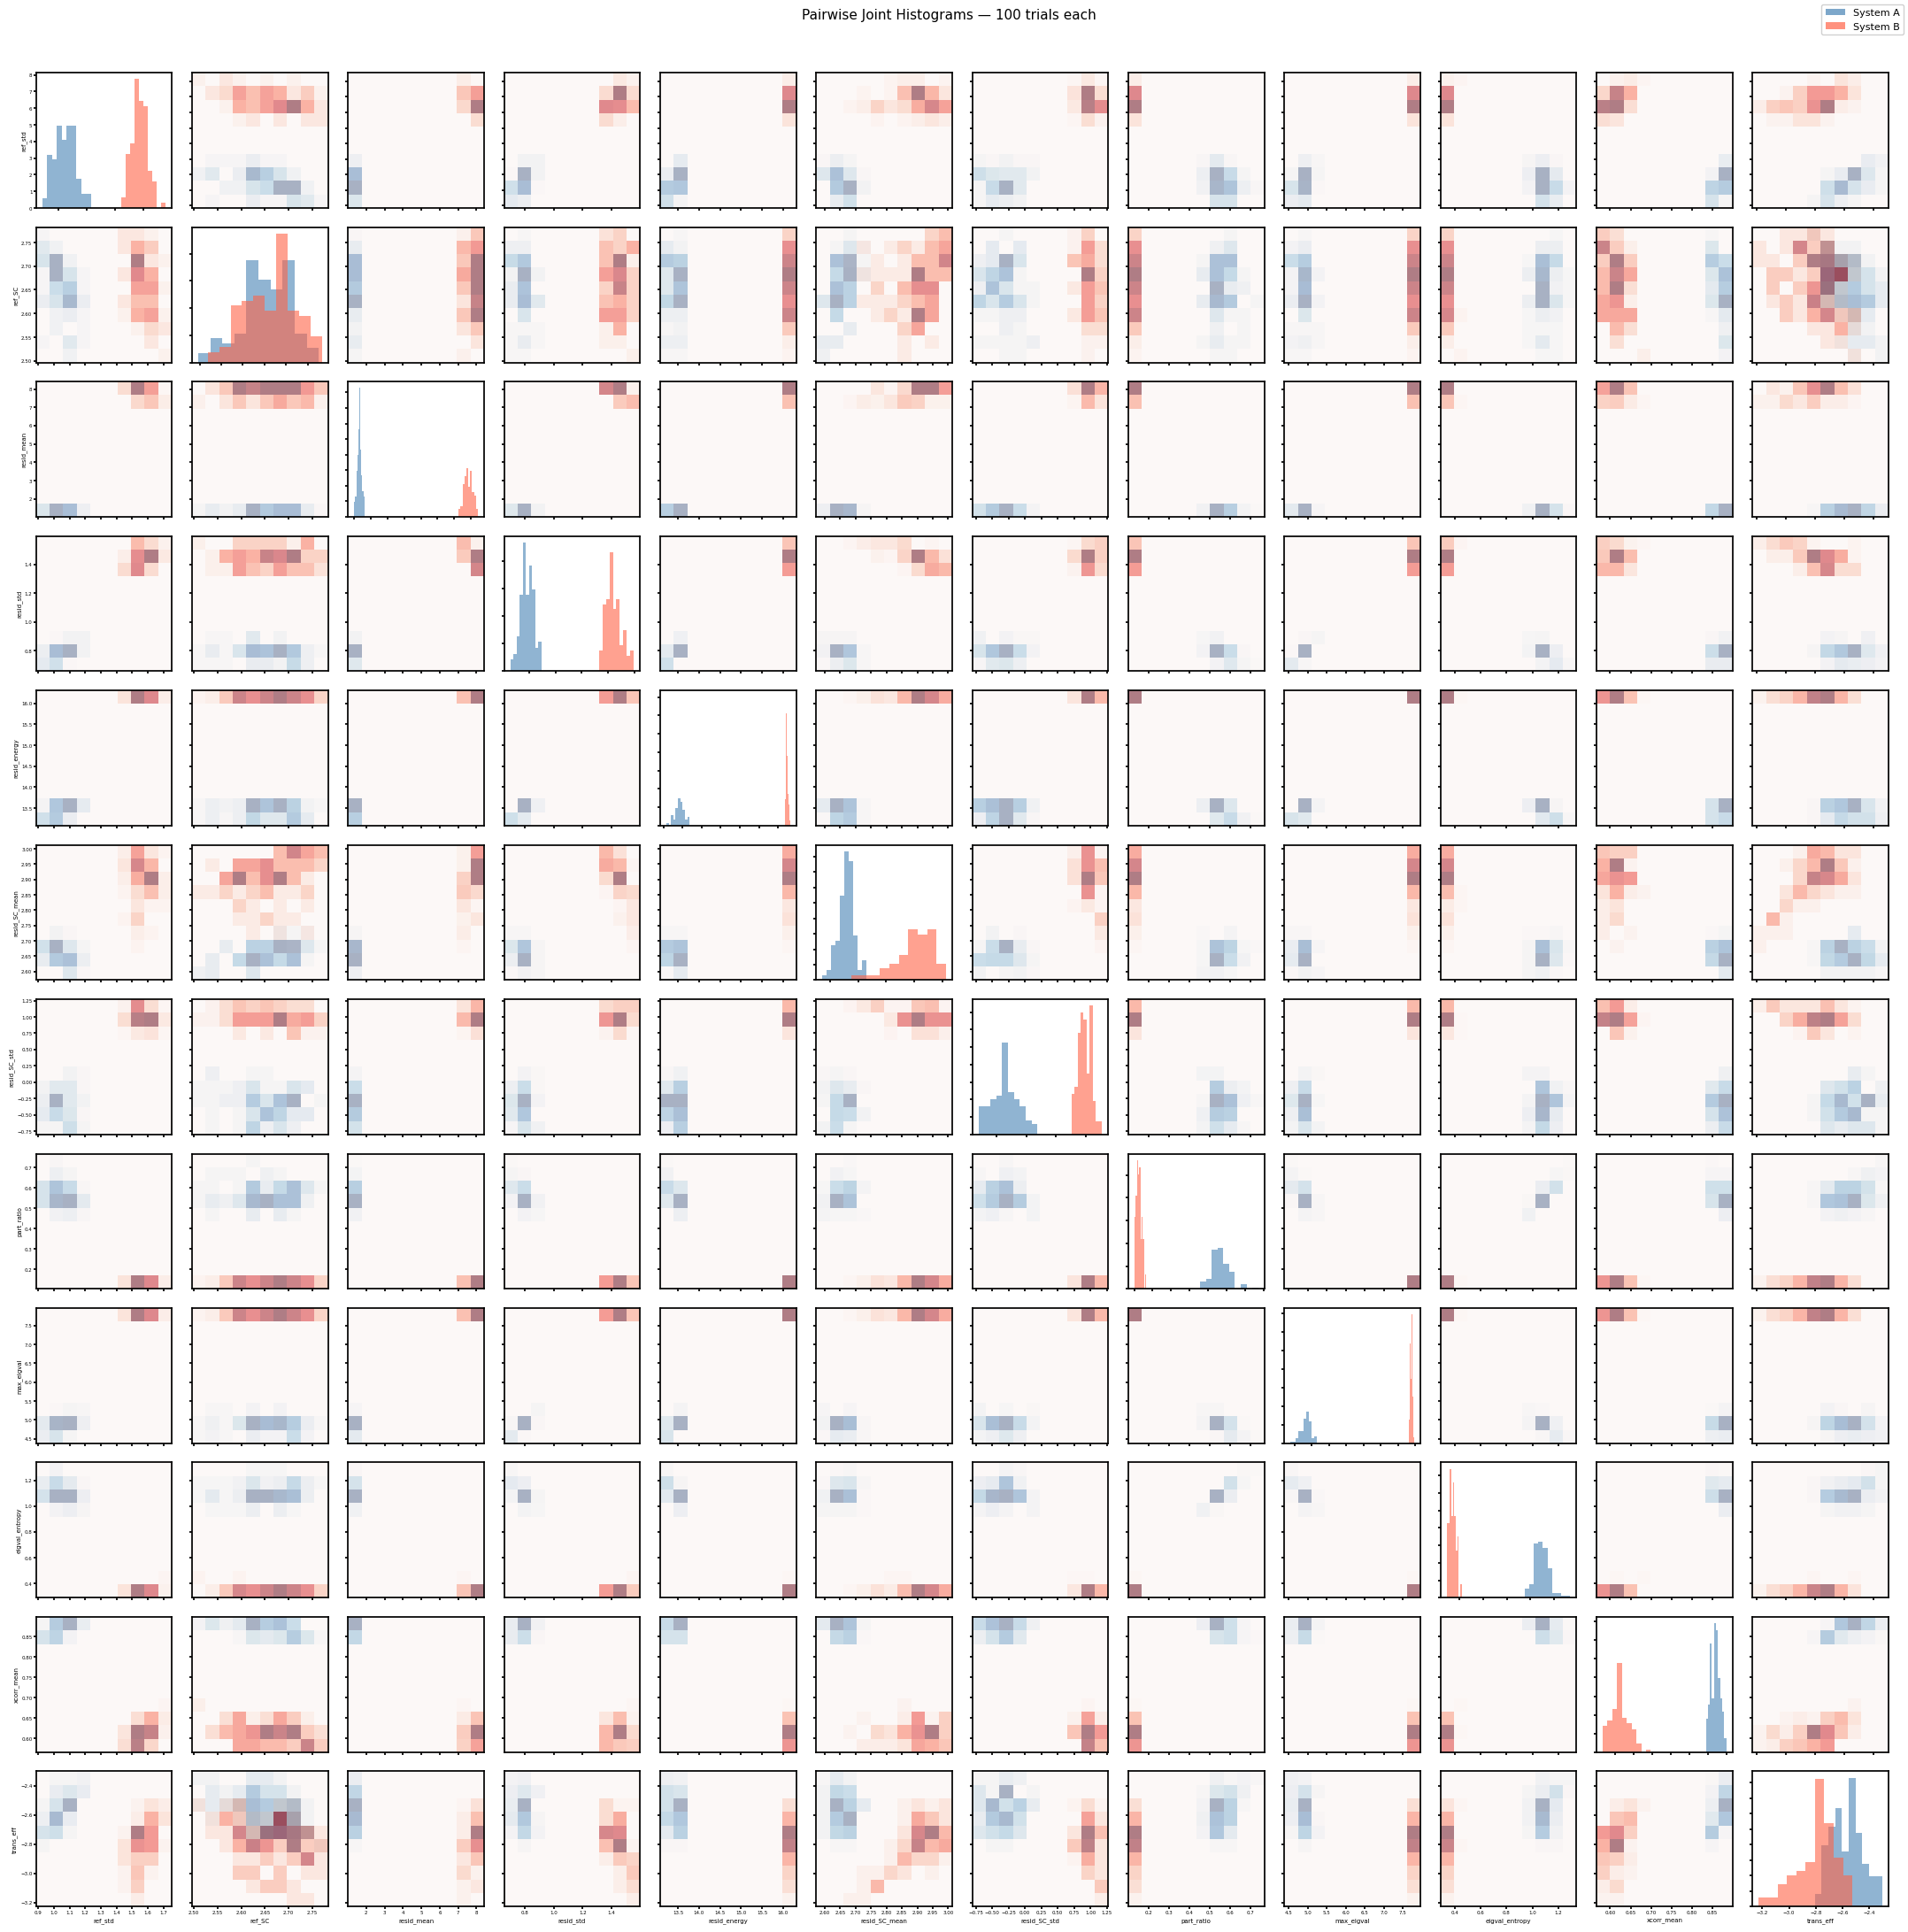

In [20]:
n_components = len(component_labels)
bins = n_bins(n_trials)

fig, axes = plt.subplots(
    n_components,
    n_components,
    figsize=(n_components * 1.8, n_components * 1.8),
    squeeze=False,
)

for row in range(n_components):
    for col in range(n_components):
        ax = axes[row, col]
        x_a, y_a = Z_A[:, col], Z_A[:, row]
        x_b, y_b = Z_B[:, col], Z_B[:, row]

        if row == col:
            ax.hist(x_a, bins=bins, color="steelblue", alpha=0.6, density=True)
            ax.hist(x_b, bins=bins, color="tomato", alpha=0.6, density=True)
        else:
            lo_x = min(x_a.min(), x_b.min())
            hi_x = max(x_a.max(), x_b.max())
            lo_y = min(y_a.min(), y_b.min())
            hi_y = max(y_a.max(), y_b.max())
            range_2d = [[lo_x, hi_x], [lo_y, hi_y]]
            ax.hist2d(x_a, y_a, bins=bins, range=range_2d, cmap="Blues", alpha=0.7)
            ax.hist2d(x_b, y_b, bins=bins, range=range_2d, cmap="Reds", alpha=0.5)

        ax.tick_params(labelsize=4, length=2, pad=1)

        if col == 0:
            ax.set_ylabel(component_labels[row], fontsize=5, labelpad=2)
        else:
            ax.set_yticklabels([])
        if row == n_components - 1:
            ax.set_xlabel(component_labels[col], fontsize=5, labelpad=2)
        else:
            ax.set_xticklabels([])

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc="steelblue", alpha=0.7, label="System A"),
    plt.Rectangle((0, 0), 1, 1, fc="tomato", alpha=0.7, label="System B"),
]
fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=8,
    framealpha=0.9,
)

fig.suptitle(
    f"Pairwise Joint Histograms — {n_trials} trials each",
    fontsize=11,
    y=1.01,
)

plt.tight_layout()
plt.show()